# Task 1: Exploratory Data Analysis (EDA)

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
#Lad Dataset
df = pd.read_csv("wine.csv")
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [37]:
#Shape
df.shape

(178, 14)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [39]:
# Summary Statistics
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [40]:
#Missing Values
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

In [41]:
#Duplicated Values
df.duplicated().sum()

np.int64(0)

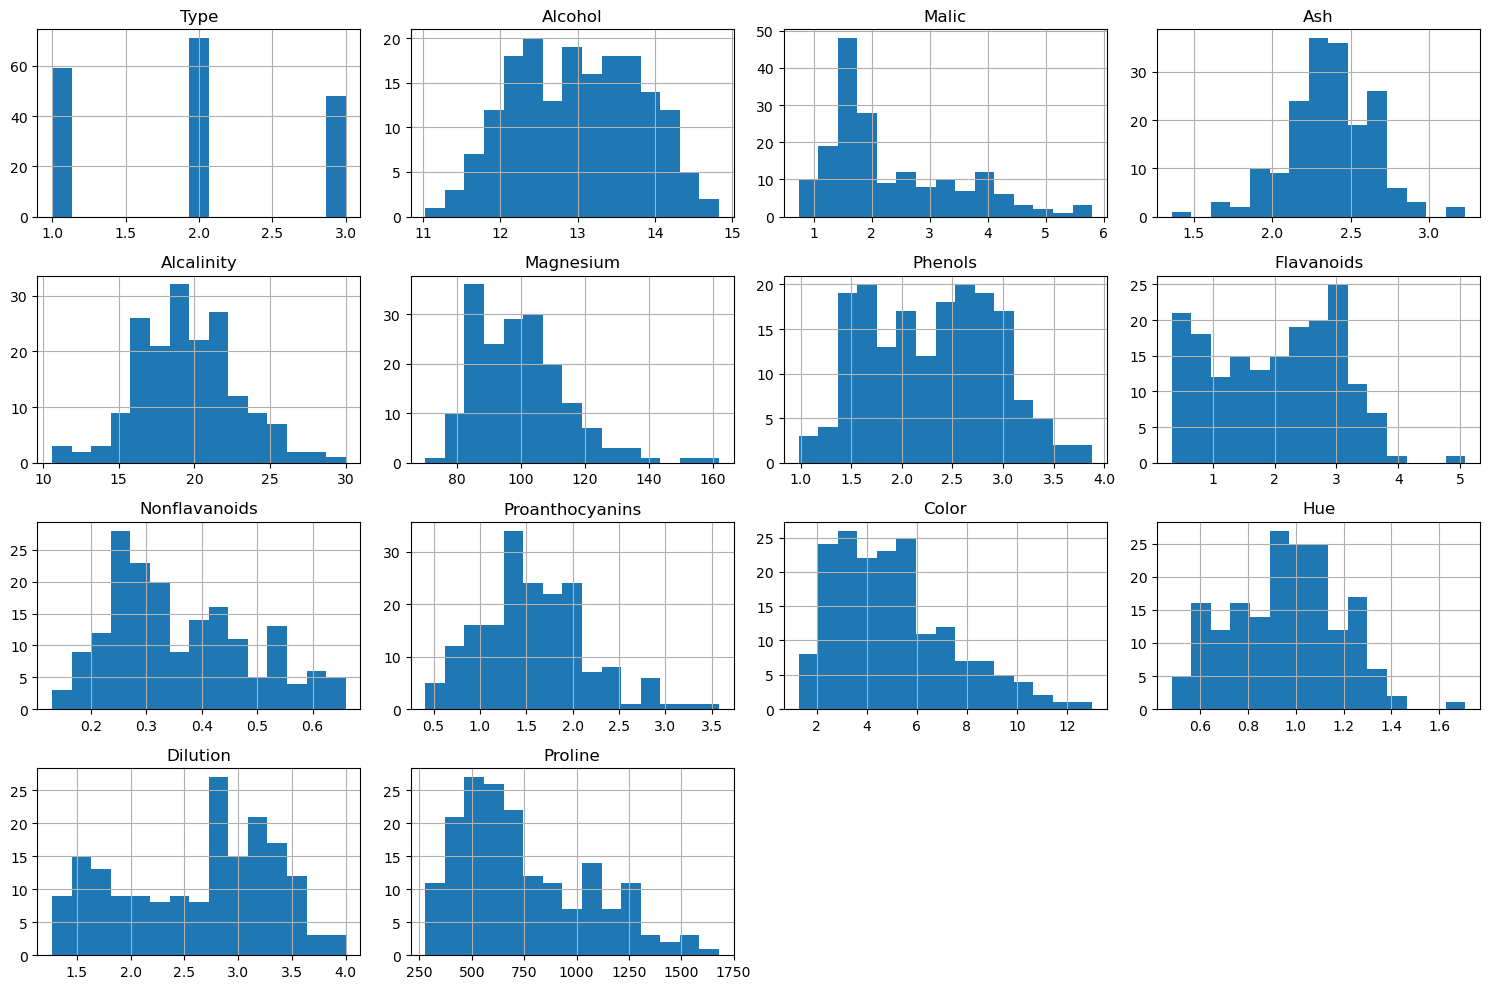

In [42]:
#Histogram
df.hist(figsize=(15,10), bins=15)
plt.tight_layout()
plt.show()

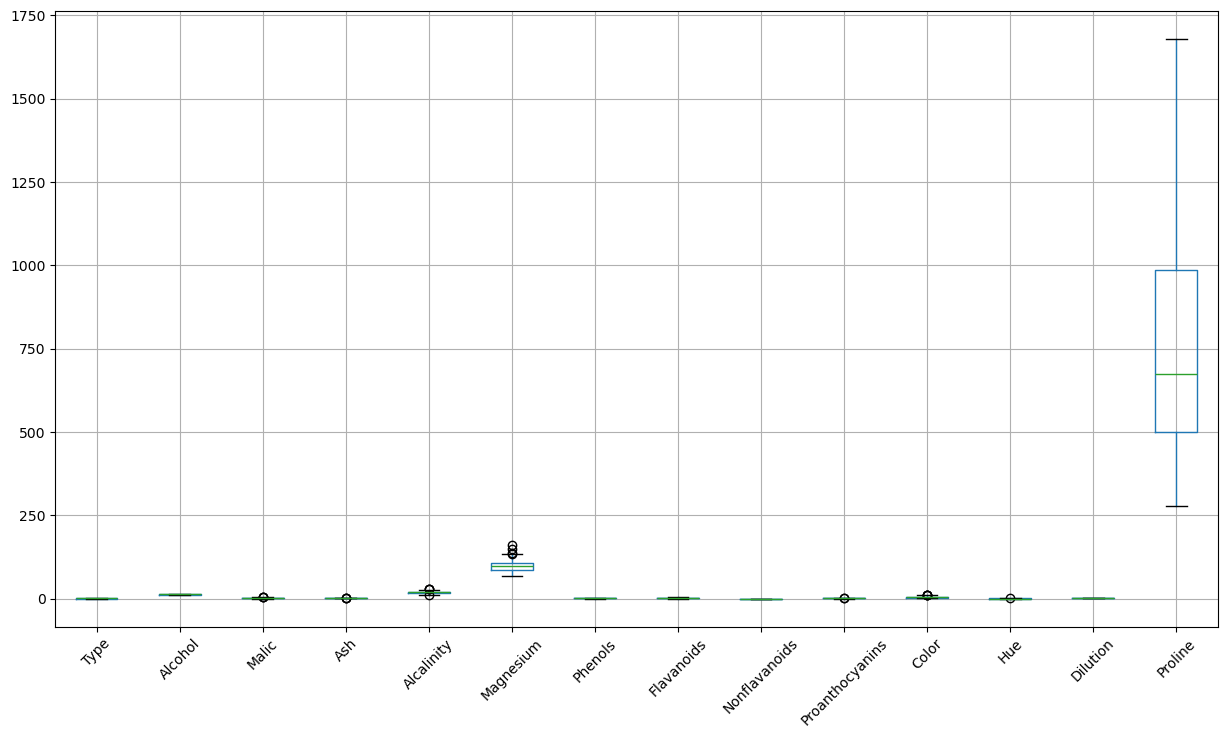

In [43]:
#Box PLot
plt.figure(figsize=(15,8))
df.boxplot()
plt.xticks(rotation=45)
plt.show()

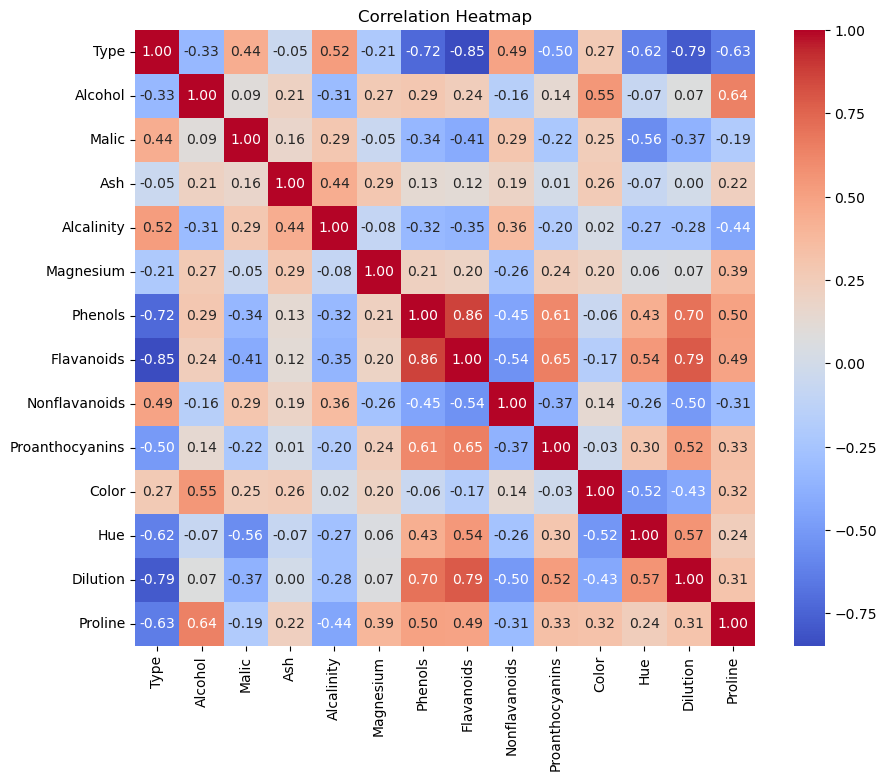

In [44]:
#Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

# Task 2: Dimensionality Reduction using PCA

In [45]:
# Standardize the Features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [46]:
#Applying PCA
from sklearn.decomposition import PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

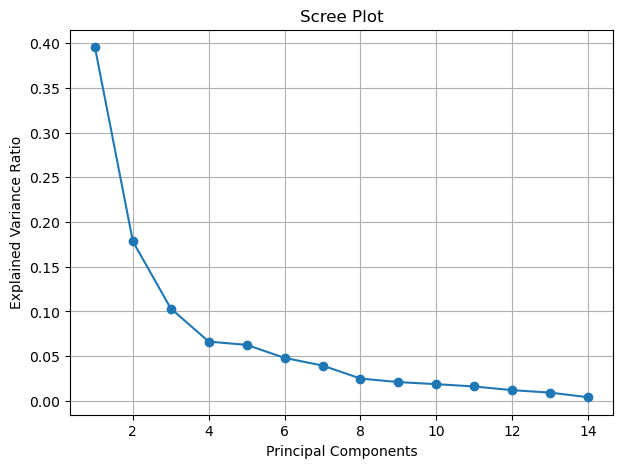

In [47]:
plt.figure(figsize=(7,5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_)+1),
    pca.explained_variance_ratio_,
    marker='o'
)
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True)

plt.show()

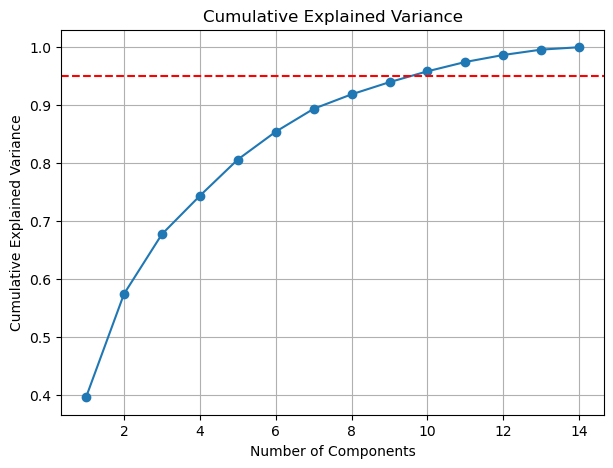

In [48]:
cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(7,5))
plt.plot(
    range(1, len(cum_var)+1),
    cum_var,
    marker='o'
)

plt.axhline(y=0.95, color='r', linestyle='--')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.grid(True)
plt.show()

In [49]:
#Finding No of Components
n_components = np.argmax(cum_var >= 0.95) + 1
print("Optimal Number of Principal Components:", n_components)

Optimal Number of Principal Components: 10


In [50]:
#Transforminng Data Set
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)
print(X_pca.shape)

(178, 10)


In [51]:
#PCA DataFrame
pca_df = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(n_components)]
)

pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,-3.522934,1.453098,-0.164795,-0.013273,0.737345,0.300716,0.573876,-0.055637,-0.458765,-1.065570
1,-2.528858,-0.330019,-2.026707,-0.417144,-0.283214,0.884309,-0.029716,-1.010372,0.218806,0.020182
2,-2.785029,1.036936,0.983238,0.664232,-0.387565,-0.468842,0.488305,0.268957,1.222769,0.106249
3,-3.922588,2.768210,-0.174968,0.565088,-0.324360,-0.262616,-0.398364,-0.618844,-0.114658,-0.107671
4,-1.407511,0.867773,2.025829,-0.440906,0.227949,0.593762,0.447876,-0.434937,-0.261548,-0.112434


# Task 3: Clustering with Original Data

C:\Users\PORUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\PORUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\PORUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\PORUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

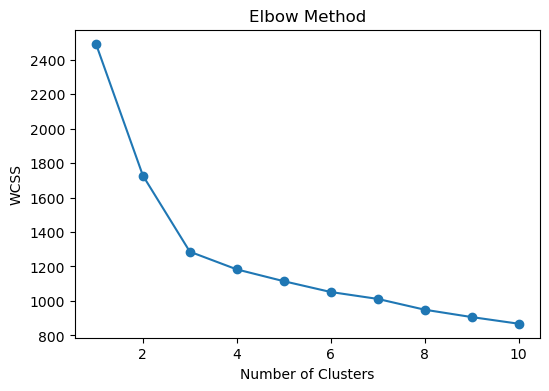

In [52]:
#Elbow Method
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [53]:
#Building K-Means Model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
clusters = kmeans.fit_predict(X_scaled)

C:\Users\PORUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


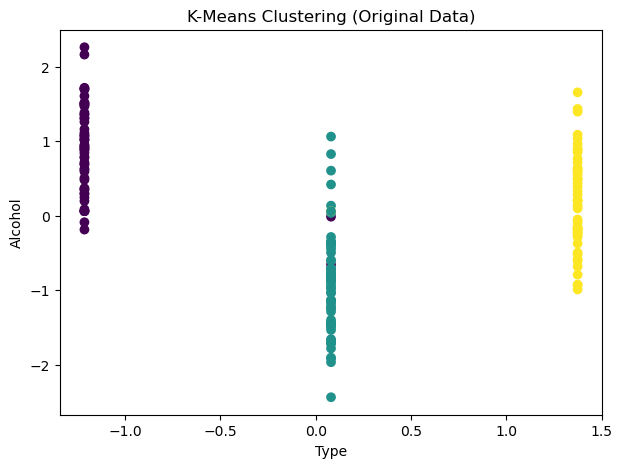

In [54]:
#Visualizing Clusters
plt.figure(figsize=(7,5))
plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters,
    cmap='viridis'
)

plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title("K-Means Clustering (Original Data)")

plt.show()

In [55]:
from sklearn.metrics import silhouette_score
silhouette = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", round(silhouette,3))

Silhouette Score: 0.308


C:\Users\PORUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\PORUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\PORUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\PORUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

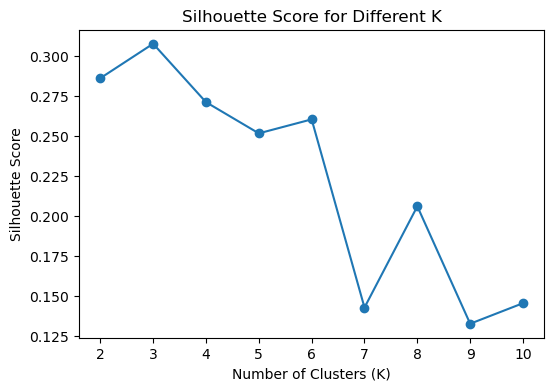

Best K: 3
Best Silhouette Score: 0.308


In [56]:
# Comparing different values of K and choose the best one:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(6,4))
plt.plot(range(2,11), scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K")
plt.show()

print("Best K:", scores.index(max(scores)) + 2)
print("Best Silhouette Score:", round(max(scores),3))

# Task 4: Clustering with PCA Data

In [57]:
# Applying K-Means on PCA Data
kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters_pca = kmeans_pca.fit_predict(X_pca)

C:\Users\PORUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


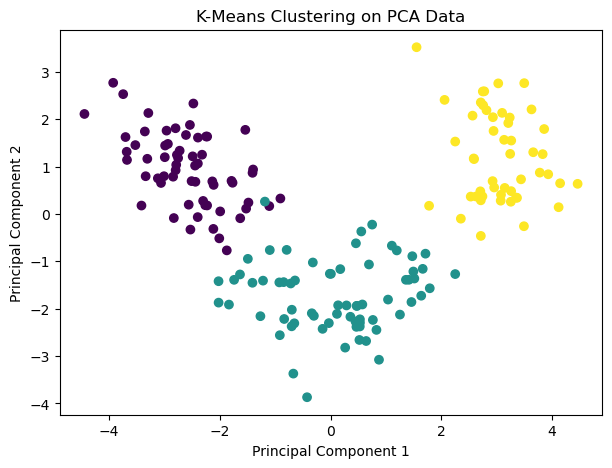

In [58]:
#Visualizing PCA Cluster
plt.figure(figsize=(7,5))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters_pca,
    cmap='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering on PCA Data")

plt.show()

In [59]:
#silhouette_score 
from sklearn.metrics import silhouette_score
silhouette_pca = silhouette_score(X_pca, clusters_pca)
print("Silhouette Score (PCA):", round(silhouette_pca,3))

Silhouette Score (PCA): 0.324


# Comparison and Analysis

In [60]:
comparison = pd.DataFrame({
    'Dataset': ['Original Data', 'PCA Data'],
    'Silhouette Score': [silhouette, silhouette_pca],
})

comparison

,Dataset,Silhouette Score
0,Original Data,0.307736
1,PCA Data,0.324066


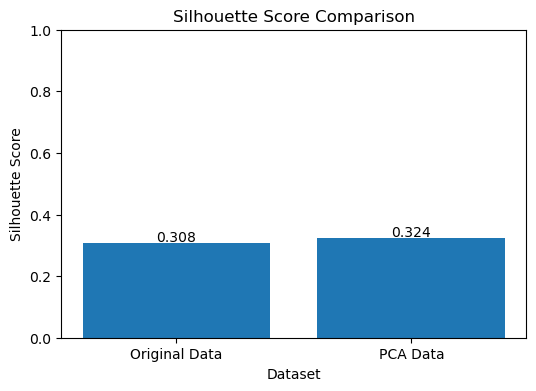

In [61]:
#Plotting
plt.figure(figsize=(6,4))
plt.bar(
    comparison['Dataset'],
    comparison['Silhouette Score']
)

plt.title("Silhouette Score Comparison")
plt.xlabel("Dataset")
plt.ylabel("Silhouette Score")

for i, v in enumerate(comparison['Silhouette Score']):
    plt.text(i, v+0.005, f"{v:.3f}", ha='center')

plt.ylim(0,1)
plt.show()

### 2.Discuss any similarities or differences observed in the clustering results.
- Both the original and PCA-transformed datasets produced meaningful clusters using K-Means.
- PCA reduced the dimensionality while preserving most of the important information.
- Differences in the Silhouette Score indicate the effect of dimensionality reduction on cluster quality.

### 3.Reflect on the impact of dimensionality reduction on clustering performance.

- PCA reduces redundant and highly correlated features before clustering.
- This decreases computational complexity and speeds up the clustering process.
- If the Silhouette Score improved, PCA enhanced cluster separation.
- If the score decreased slightly, some useful information may have been lost during dimensionality reduction.
- Overall, PCA provides a more efficient representation of the data for clustering.

### 4. Analyze the trade-offs between using PCA and clustering directly on the original dataset.
- Original data retains all features and information but requires more computation and may contain redundant features.
- PCA reduces dimensionality, removes redundancy, and speeds up clustering but may lose some information.
- PCA is preferred for high-dimensional datasets, while the original data is better when feature interpretation is important.

# Task 6: Conclusion and Insights

#### 1. Summarize the key findings and insights from the assignment.
- PCA successfully reduced the dimensionality while preserving most of the important information.
- K-Means clustering was applied to both the original and PCA-transformed datasets for comparison.
- The clustering quality was evaluated using the Silhouette Score, helping identify the better clustering approach.

#### 2. Discuss the practical implications of using PCA and clustering in data analysis.
- PCA helps simplify large datasets, making analysis faster and more efficient.
- Clustering groups similar observations, enabling pattern discovery without labeled data.Together, PCA and clustering are useful for customer segmentation, anomaly detection, and data visualization.

#### 3.Provide recommendations for when to use each technique based on the analysis conducted.
- Use PCA when dealing with high-dimensional or highly correlated data to reduce complexity.
- Use clustering on the original dataset when preserving all feature information and interpretability is important.